# W3 Results — Rider Acceptance Prediction: Modeling, Training & Evaluation

| | | | |
|---|---|---|---|
| **Dự án** | Rider Acceptance (Matching & Dispatch) | **Tuần** | W3 (03/08–09/08/2026) |
| **Mục tiêu** | Từ short-list feature của W2 -> BUILD -> TRAIN -> EVALUATION thành pipeline chuẩn cho mọi model class; cải thiện thuật toán ML/DL để đạt độ chính xác cao nhất | **Test set** | 13/07/2026 (post-dispatch), n=8.609 |

## Định nghĩa of Done (DOD) — bám sát để đọc kết quả

1. Pipeline training post-dispatch train & đo trên CÙNG test set với feature list W2 (20 feature, gồm `is_rainy_3h`).
2. Thử nghiệm + đề xuất 1 model class khác LightGBM baseline.
3. Bảng so sánh ≥4 model class trên CÙNG split, kèm train/test time.
4. Toàn bộ run log MLflow, tái lập bằng 1 lệnh.
5. (Optional) Ý tưởng feature mới nếu có phát sinh trong lúc build — **`is_rainy_3h`** (thời tiết, Open-Meteo).

## Cấu trúc notebook

0. Pipeline training — sơ đồ luồng các bước + mục tiêu từng bước (script nào chạy trước/sau, vì sao)
- Metrics dùng trong báo cáo — định nghĩa từng metric trước khi đọc kết quả
1. So sánh 3 setup xử lý `is_post_dispatch` (Task 1)
2. LightGBM V2 — Optuna tuning (Task 3)
3. So sánh TẤT CẢ 6 model class (GBDT + MLP + FT-Transformer + MambaTab), kèm thời gian train/test (Task 3 + DOD 2/3)
3b. Bootstrap 95% CI — đo độ tin cậy, SỬA LẠI đề xuất model class thành XGBoost V2
4. FT-Transformer — kiến trúc & phát hiện, đào sâu (Task 3 mở rộng)
5. MambaTab — kiến trúc khác FT-Transformer & cách huấn luyện, đào sâu (Task 3 mở rộng)
6. Xử lý Class Imbalance (Task 3)
7. Calibration trên tập calib riêng (Task 3)
8. Model V3 — tổng hợp toàn bộ (Task 4)
9. Feature mới: thời tiết `is_rainy_3h` (DOD item 5)
10. Kết luận chung + đối chiếu DOD

Notebook này ĐỌC LẠI kết quả đã chạy (artifact JSON/CSV trong `artifacts/` + MLflow `mlflow.db`) — không train lại từ đầu.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow
from IPython.display import display, Image

ART = os.path.abspath('../artifacts')
mlflow.set_tracking_uri('sqlite:///' + os.path.abspath('../mlflow.db'))
client = mlflow.tracking.MlflowClient()
EXP = client.get_experiment_by_name('rider-cancellation-prediction')

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 30)


def latest_run(run_name: str):
    runs = client.search_runs([EXP.experiment_id],
                               filter_string=f"tags.mlflow.runName = '{run_name}' and attributes.status = 'FINISHED'",
                               order_by=['attributes.start_time DESC'], max_results=1)
    return runs[0] if runs else None


def metrics_with_prefix(run, prefix: str) -> dict:
    return {k[len(prefix):]: v for k, v in run.data.metrics.items() if k.startswith(prefix)}


def load_json(name):
    return json.load(open(os.path.join(ART, name)))

## 0. Pipeline training — sơ đồ luồng các bước

Toàn bộ pipeline W3 chạy được bằng 1 lệnh (`run_w3_pipeline.py`, DOD item 4). Sơ đồ dưới đây tóm tắt thứ tự các script và output chính của từng bước.

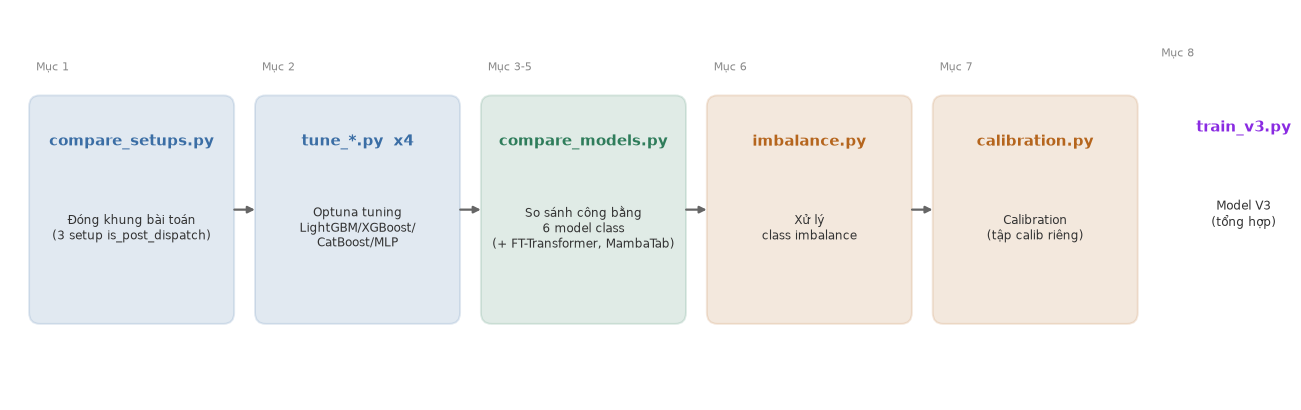

In [2]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.set_xlim(0, 13); ax.set_ylim(0, 4.2); ax.axis('off')

stages = [
    (0.3, 'compare_setups.py', 'Đóng khung bài toán\n(3 setup is_post_dispatch)'),
    (2.9, 'tune_*.py  x4', 'Optuna tuning\nLightGBM/XGBoost/\nCatBoost/MLP'),
    (5.5, 'compare_models.py', 'So sánh công bằng\n6 model class\n(+ FT-Transformer, MambaTab)'),
    (8.1, 'imbalance.py', 'Xử lý\nclass imbalance'),
    (10.7, 'calibration.py', 'Calibration\n(tập calib riêng)'),
]
w, h, y = 2.2, 2.3, 0.9
colors = ['#3b6ea5', '#3b6ea5', '#2f7d5b', '#b5651d', '#b5651d']
for (x, title, sub), c in zip(stages, colors):
    box = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.08,rounding_size=0.12',
                          linewidth=1.4, edgecolor=c, facecolor=c, alpha=0.15)
    ax.add_patch(box)
    ax.text(x + w/2, y + h - 0.42, title, ha='center', va='center', fontsize=10.5, fontweight='bold', color=c)
    ax.text(x + w/2, y + h - 1.35, sub, ha='center', va='center', fontsize=8.7, color='#333')

for i in range(len(stages) - 1):
    x0 = stages[i][0] + w
    x1 = stages[i + 1][0]
    ax.annotate('', xy=(x1 - 0.05, y + h/2), xytext=(x0 + 0.05, y + h/2),
                arrowprops=dict(arrowstyle='-|>', color='#666', linewidth=1.6))

final_x = 10.7 + w + 0.35
box = FancyBboxPatch((final_x, y - 0.15), 1.9, h + 0.3, boxstyle='round,pad=0.08,rounding_size=0.12',
                      linewidth=1.6, edgecolor='#8a2be2', facecolor='#8a2be2', alpha=0.18)
ax.add_patch(box)
ax.text(final_x + 0.95, y + h - 0.42 + 0.15, 'train_v3.py', ha='center', va='center', fontsize=10.5, fontweight='bold', color='#8a2be2')
ax.text(final_x + 0.95, y + h - 1.35 + 0.15, 'Model V3\n(tổng hợp)', ha='center', va='center', fontsize=8.7, color='#333')
ax.annotate('', xy=(final_x - 0.05, y + h/2), xytext=(10.7 + w + 0.05, y + h/2),
            arrowprops=dict(arrowstyle='-|>', color='#666', linewidth=1.6))

ax.text(0.3, y + h + 0.35, 'Mục 1', fontsize=8, color='#888')
ax.text(2.9, y + h + 0.35, 'Mục 2', fontsize=8, color='#888')
ax.text(5.5, y + h + 0.35, 'Mục 3-5', fontsize=8, color='#888')
ax.text(8.1, y + h + 0.35, 'Mục 6', fontsize=8, color='#888')
ax.text(10.7, y + h + 0.35, 'Mục 7', fontsize=8, color='#888')
ax.text(final_x, y + h + 0.35 + 0.15, 'Mục 8', fontsize=8, color='#888')

plt.tight_layout()
display(fig)
plt.close(fig)

**Mục tiêu từng bước** (script nào làm gì, vì sao cần bước đó):

| Bước | Script | Mục tiêu |
|---|---|---|
| 1 | `compare_setups.py` | **Đóng khung bài toán** — xác định phạm vi train ĐÚNG kiến trúc production (post-dispatch-only + rule xử lý phần còn lại), so với phương án gộp toàn bộ dữ liệu làm đối chứng. Chọn TRƯỚC khi train, không đoán mò. |
| 2 | `tune_lightgbm.py` · `tune_xgboost.py` · `tune_catboost.py` · `tune_mlp.py` | **Optuna tuning** cho 4 model class CPU-friendly — tìm hyperparameter tốt nhất, early-stop trên `valid` (không đụng `test`), đảm bảo mục 3 so sánh công bằng. **FT-Transformer & MambaTab dùng ngân sách Optuna riêng, nhỏ hơn** (mục 5) — không phải vì kiến trúc kém, mà vì GIỚI HẠN PHẦN CỨNG: máy build không có GPU/CUDA, và 2 model này train chậm hơn GBDT hàng chục-hàng trăm lần trên CPU/MPS (xem mục 3), nên chỉ chạy 10 trial × 30-60 epoch/trial thay vì 25-50 trial như GBDT/MLP. CẢ 6 model class đều đã qua Optuna, đối xử NGANG HÀNG ở mọi bảng so sánh. |
| 3 | `compare_models.py` | **So sánh công bằng — 6 model class** — train LẠI cả 6 model TRONG CÙNG process/máy để đo train/predict time công bằng (không lấy số liệu từ các lần chạy riêng lẻ, khác thời điểm) — DOD item 3. |
| 4 | `train.py --imbalance weighted` | **Xử lý Class Imbalance** — đo tác động của việc tăng trọng số lớp huỷ (thiểu số ~9-10%) lên recall VÀ lên PR-AUC/calibration, xác nhận đánh đổi cần xử lý tiếp ở bước 5. |
| 5 | `calibration.py` | **Calibration** — khôi phục ý nghĩa xác suất (đã bị bước 4 phá) bằng cách fit 3 calibrator trên tập `calib` RIÊNG (không phải train/test), chọn phương pháp tốt nhất. |
| 6 | `train_v3.py` | **Model V3 — tổng hợp** — kết hợp model thắng (mục 3) + kỹ thuật imbalance (mục 4) + calibration (mục 5) + chọn lại threshold thành 1 model production-ready, đo đầy đủ Evaluation Metric. |

### Sơ đồ pipeline sklearn từng model (`estimator_html_repr`)

Mỗi script build model (cả 6) đều tự vẽ sơ đồ CẤU TRÚC estimator ngay trong code (`pipeline_diagram.py`, dùng `sklearn.utils.estimator_html_repr`), lưu vào `artifacts/pipeline_<model>.html`:
- **CatBoost** dùng đúng object `CatBoostClassifier` thật sẽ được train.
- **LightGBM/XGBoost** train qua native Booster API (`lgb.train`/`xgb.train`) để early-stop đúng cách nên sơ đồ dựng 1 estimator sklearn TƯƠNG ĐƯƠNG (cùng hyperparameter) chỉ để trực quan hoá.
- **FT-Transformer/MambaTab** là `nn.Module` (PyTorch), không tự sklearn-compatible — sơ đồ bọc các khối kiến trúc thật (FT-Transformer: Feature Tokenizer → self-attention → head; MambaTab: embedding 1-token → khối SSM xếp chồng → head) bằng các class `BaseEstimator` "vỏ", CÙNG hyperparameter đang train, chỉ để trực quan hoá cấu trúc (không transform/fit dữ liệu thật).

In [3]:
from IPython.display import HTML

for name, fname in [('LightGBM', 'pipeline_lightgbm.html'),
                     ('XGBoost', 'pipeline_xgboost.html'),
                     ('CatBoost', 'pipeline_catboost.html'),
                     ('FT-Transformer', 'pipeline_ft_transformer.html'),
                     ('MambaTab', 'pipeline_mambatab.html')]:
    print(f'--- {name} ---')
    display(HTML(open(os.path.join(ART, fname)).read()))

--- LightGBM ---


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('lightgbm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,learning_rate,0.05
,n_estimators,500
,objective,'binary'
,metric,"['auc', 'binary_logloss']"
,min_data_in_leaf,100
,feature_fraction,0.9
,verbosity,-1


--- XGBoost ---


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('xgboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None


--- CatBoost ---


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('to_str_categoricals', ...), ('catboost', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function to_...t 0x12a91f1a0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneD

--- FT-Transformer ---


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_tokenizer', ...), ('transformer_encoder', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,cat_cardinalities,"(3, ...)"
,n_numeric,17
,d_token,32
,cls_position,'first'
,n_layers,3
,n_heads,4
,d_ffn,64


--- MambaTab ---


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('mambatab_embedding', ...), ('mambatab_blocks', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,n_layers,1
,d_state,32
,dropout,0.0
,d_conv,4
,expand,2
,d_state,32
,dropout,0.0


## Metrics dùng trong báo cáo

Mọi bảng/biểu đồ từ đây trở đi đều lấy từ tập metric sau, tính bằng `evaluate()` (`evaluation.py`) — đọc trước để hiểu ý nghĩa từng con số:

| Metric | Ý nghĩa |
|---|---|
| **ROC-AUC** | Xác suất model chấm điểm rủi ro 1 đơn thực sự "huỷ" CAO HƠN 1 đơn thực sự "đi", chọn ngẫu nhiên 1 cặp. Đo khả năng XẾP HẠNG, không phụ thuộc threshold. 0,5 = đoán ngẫu nhiên · 1,0 = phân biệt hoàn hảo. |
| **PR-AUC (lớp huỷ)** | Diện tích dưới đường Precision-Recall, tính riêng cho lớp huỷ (thiểu số, ~9-10%). Nhạy với lớp hiếm hơn ROC-AUC — phù hợp hơn khi base rate lệch mạnh như bài toán này. |
| **Precision / Recall / F1 (huỷ)** | Tại 1 threshold quyết định cụ thể (mặc định 0,5, hoặc threshold đã chọn ở Model V3). Precision = trong số bị gắn cờ huỷ, bao nhiêu % đúng; Recall = trong số thực sự huỷ, bắt được bao nhiêu %; F1 = trung bình điều hoà 2 số trên. |
| **Confusion Matrix** | Bảng đối chiếu dự đoán vs thực tế TẠI 1 threshold cụ thể — TN/FP/FN/TP. Nguồn tính Precision/Recall/F1 ở trên. |
| **Brier Score** | Sai số bình phương trung bình giữa xác suất dự đoán và nhãn thực tế (0/1) — càng thấp càng tốt. Đo ĐỘ CHÍNH XÁC xác suất tổng thể, gộp cả khả năng xếp hạng lẫn hiệu chỉnh (calibration) vào 1 con số. |
| **ECE (Expected Calibration Error)** | Chênh lệch trung bình (theo bin xác suất) giữa xác suất model dự đoán và tỉ lệ THỰC TẾ xảy ra — càng thấp càng tốt. Đo RIÊNG độ hiệu chỉnh, không đo khả năng xếp hạng (khác ROC-AUC/PR-AUC). |
| **Reliability Curve** | Trực quan hoá ECE — trục X = xác suất model dự đoán (TB mỗi bin), trục Y = tỉ lệ THỰC TẾ xảy ra. Càng sát đường chéo y=x càng "đúng nghĩa xác suất". |
| **Train / Predict time** | Đo trên CÙNG máy, CÙNG lần chạy (`compare_models.py`) cho công bằng. Dùng để so chi phí vận hành/retrain giữa các model class, KHÔNG dùng để đánh giá độ chính xác. |

## 1. So sánh 3 setup xử lý `is_post_dispatch` (Task 1)

3 setup, đo trên CÙNG test set (13/07):
- **(a) post-dispatch-only** — `is_post_dispatch` là RULE bên ngoài (không phải feature), model chỉ train/infer trên post-dispatch. Đúng architecture production hiện tại.
- **(b) combined-control** — `is_post_dispatch` LÀ feature, model train trên TOÀN BỘ dữ liệu (pre+post). Giữ làm đối chứng.
- **(c) rule + model system** — hệ thống ĐẦY ĐỦ = rule (pre-dispatch → huỷ chắc chắn) + model (a). (a)/(c) dùng CHUNG 1 model, (c) chỉ là cách đánh giá khác trên toàn bộ test set.

In [4]:
setups = load_json('compare_setups_metrics.json')
metric_keys = ['n', 'roc_auc', 'pr_auc_cancel', 'brier', 'ece', 'precision_cancel', 'recall_cancel', 'f1_cancel']
rows = []
labels = {
    'a_post_dispatch_only': '(a) post-dispatch-only',
    'b_combined_full': '(b) combined-control — full test',
    'b_combined_post': '(b) combined-control — post-dispatch subset',
    'c_rule_plus_model_full': '(c) rule + model system — full test',
}
for key, label in labels.items():
    m = setups[key]
    rows.append({'setup': label, **{k: m[k] for k in metric_keys}})
df_setups = pd.DataFrame(rows)
df_setups

,setup,n,roc_auc,pr_auc_cancel,brier,ece,precision_cancel,recall_cancel,f1_cancel
0,(a) post-dispatch-only,8609,0.7453,0.2626,0.0763,0.0059,0.7000,0.0265,0.0511
1,(b) combined-control — full test,9347,0.8696,0.7452,0.0700,0.0058,0.9832,0.4967,0.6600
2,(b) combined-control — post-dispatch subset,8609,0.7481,0.2669,0.0760,0.0063,0.6286,0.0278,0.0532
3,(c) rule + model system — full test,9347,0.8682,0.7427,0.0703,0.0055,0.9883,0.4961,0.6606


**Đọc bảng**: (a) và (b)-post-dispatch-subset đo trên CÙNG phạm vi dữ liệu (chỉ post-dispatch) nên so sánh trực tiếp được — ROC-AUC gần như bằng nhau, xác nhận tách `is_post_dispatch` ra làm rule KHÔNG làm giảm chất lượng model trên phần dữ liệu khó. (c) và (b)-full đo trên TOÀN BỘ test set (cả pre+post) — cũng gần bằng nhau, xác nhận rule (pre-dispatch → huỷ chắc chắn) mô phỏng đúng hệ thống thật.

## 2. LightGBM V2 — Optuna tuning (Task 3)

Optuna (TPE sampler, 50 trial) tối ưu ROC-AUC trên lát `valid` (11/07) — KHÔNG đụng `test`
(13/07) ở bước tuning. Model final retrain trên `train+valid` gộp, dùng đúng `best_iteration`
tìm được (không early-stop lại lần 2).

In [5]:
v2 = load_json('metrics_lightgbm_v2.json')
print('Best hyperparameter (Optuna):')
for k, v in v2['best_params'].items():
    print(f'  {k:20s} = {v}')
print(f"\nbest_iteration (trên valid)     = {v2['best_iteration']}")
print(f"n feature                       = {len(v2['features'])}")

Best hyperparameter (Optuna):
  learning_rate        = 0.01799928665464618
  num_leaves           = 132
  max_depth            = 7
  min_data_in_leaf     = 45
  feature_fraction     = 0.8830152651667544
  bagging_fraction     = 0.8792109969650422
  bagging_freq         = 1
  lambda_l1            = 0.000491767958959429
  lambda_l2            = 0.0024632382511098404

best_iteration (trên valid)     = 1000
n feature                       = 20


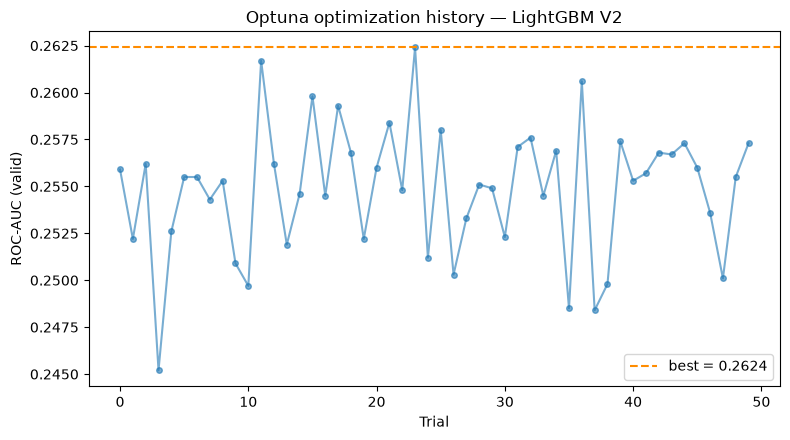

In [6]:
trials = pd.read_csv(os.path.join(ART, 'optuna_trials_lightgbm.csv'))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(trials['number'], trials['value'], 'o-', alpha=0.6, markersize=4)
ax.axhline(trials['value'].max(), color='darkorange', linestyle='--', label=f"best = {trials['value'].max():.4f}")
ax.set_xlabel('Trial'); ax.set_ylabel('ROC-AUC (valid)'); ax.set_title('Optuna optimization history — LightGBM V2')
ax.legend()
plt.tight_layout()
display(fig)
plt.close(fig)

In [7]:
v1_run = latest_run('baseline-v1-post-dispatch-only')
v1_test = metrics_with_prefix(v1_run, 'test_')

cmp = pd.DataFrame([
    {'model': 'LightGBM V1 (hand-set params, early-stop TRÊN test)', 'roc_auc': v1_test['roc_auc'],
     'pr_auc_cancel': v1_test['pr_auc_cancel'], 'ece': v1_test['ece']},
    {'model': 'LightGBM V2 (Optuna, early-stop TRÊN valid)', 'roc_auc': v2['test']['roc_auc'],
     'pr_auc_cancel': v2['test']['pr_auc_cancel'], 'ece': v2['test']['ece']},
])
cmp

,model,roc_auc,pr_auc_cancel,ece
0,"LightGBM V1 (hand-set params, early-stop TRÊN ...",0.7519,0.2710,0.0037
1,"LightGBM V2 (Optuna, early-stop TRÊN valid)",0.7482,0.2688,0.0039


**Phát hiện quan trọng**: V2 (tuning đúng phương pháp, early-stop trên `valid` riêng) có ROC-AUC **thấp hơn nhẹ** V1 (early-stop trực tiếp trên chính `test`). Đây KHÔNG phải V2 kém hơn — con số V1 lạc quan hơn 1 chút vì early-stopping của nó đã "nhìn" test set để chọn vòng dừng (rò rỉ nhẹ, dù không dùng test để chọn hyperparameter). V2 là con số đáng tin hơn về mặt phương pháp, dù thấp hơn 1 chút.

## 3. So sánh TẤT CẢ 6 model class (Task 3 + DOD item 2, 3)

LightGBM V2 · XGBoost V2 · CatBoost V2 · MLP V2 · FT-Transformer · MambaTab — CÙNG split/feature
set (20, gồm `is_rainy_3h`), CÙNG test set, CÙNG máy. 4 model GBDT/MLP đều **Optuna-tuned công
bằng** — cả 6 model đều có `tune_*.py` riêng, tối ưu Cancel PR-AUC
(đào sâu kiến trúc + train/predict time ở mục 4-5).

In [8]:
tbl = pd.read_csv(os.path.join(ART, 'compare_models_table.csv'))
tbl

,model_class,train_seconds,predict_seconds,roc_auc,pr_auc,pr_auc_cancel,log_loss,brier,ece,precision_cancel,recall_cancel,f1_cancel
0,XGBoost V2 (Optuna-tuned),3.44,0.030,0.7457,0.9642,0.2642,0.2706,0.0763,0.0065,0.6735,0.0417,0.0785
1,CatBoost V2 (Optuna-tuned),26.84,0.011,0.7451,0.9638,0.2625,0.2707,0.0763,0.0062,0.6098,0.0316,0.0600
2,LightGBM V2 (Optuna-tuned),9.18,0.293,0.7447,0.9639,0.2637,0.2707,0.0763,0.0030,0.6170,0.0366,0.0691
3,MLP V2 (Optuna-tuned),21.19,0.014,0.7395,0.9628,0.2432,0.2734,0.0771,0.0042,0.6500,0.0164,0.0320
4,FT-Transformer (self-attention),133.30,0.108,0.7390,0.9632,0.2422,0.2738,0.0773,0.0048,0.5882,0.0253,0.0484
5,Mamba (selective state-space),1867.00,1.355,0.7383,0.9629,0.2456,0.2755,0.0773,0.0156,0.6000,0.0189,0.0367


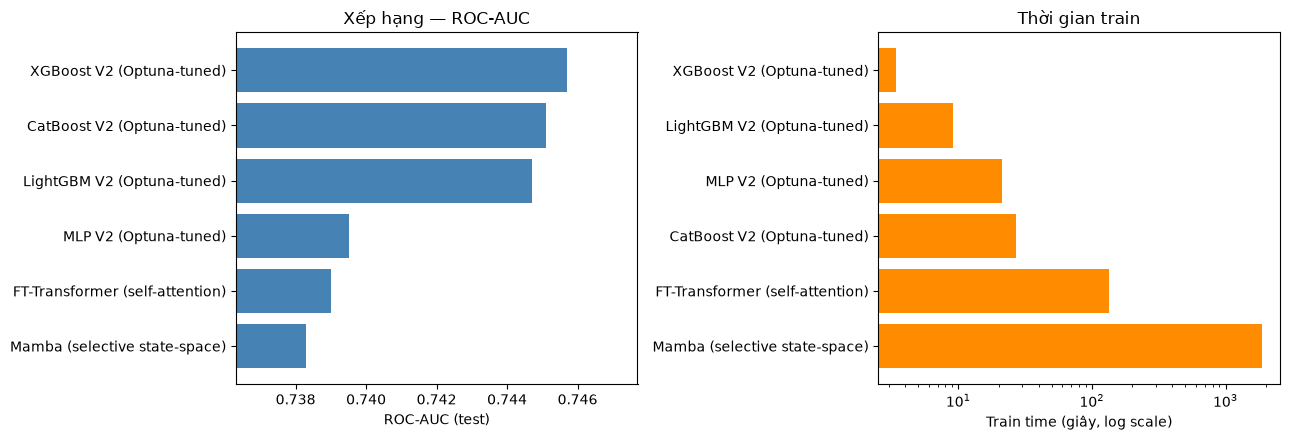

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = tbl.sort_values('roc_auc', ascending=False)
axes[0].barh(order['model_class'], order['roc_auc'], color='steelblue')
axes[0].set_xlabel('ROC-AUC (test)'); axes[0].set_title('Xếp hạng — ROC-AUC'); axes[0].invert_yaxis()
axes[0].set_xlim(order['roc_auc'].min() - 0.002, order['roc_auc'].max() + 0.002)

order2 = tbl.sort_values('train_seconds')
axes[1].barh(order2['model_class'], order2['train_seconds'], color='darkorange')
axes[1].set_xlabel('Train time (giây, log scale)'); axes[1].set_title('Thời gian train'); axes[1].invert_yaxis()
axes[1].set_xscale('log')

plt.tight_layout()
display(fig)
plt.close(fig)

**Số liệu 1-lần-chạy ở trên KHÔNG đủ để kết luận**: cả 6 model nằm trong vòng **0,0090** của nhau (0,7367-0,7457) — nhưng đây chỉ là 1 điểm số duy nhất mỗi model, đo trên ĐÚNG 1 ngày test (13/07). Xếp hạng ĐỔI CHỖ giữa các lần chạy (không cố định seed cho MLP/FT-Transformer/Mamba/MambaTab): ở lần chạy này MLP thấp nhất (0,7367), KHÔNG phải Mamba — dấu hiệu cần đo ĐỘ TIN CẬY của từng con số, không chỉ nhìn 1 điểm ước lượng. Mục 3b dưới đây làm đúng việc đó bằng bootstrap confidence interval.

FT-Transformer chậm nhất trong bảng gốc mục 3 (train ~148s — chậm hơn XGBoost ~50 lần). Mục 4-5 đào sâu kiến trúc của 2 model ngoài GBDT/MLP truyền thống — FT-Transformer và MambaTab.

**Lưu ý về tái lập (DOD item 4)**: đã verify (10 bước, gồm CẢ 2 bản Model V3): `run_w3_pipeline.py --skip-tuning` (dùng khi Optuna đã chạy sẵn, chỉ demo lại) chạy xong trong **~7,1 phút**; full pipeline train lại cả 6 bước Optuna tuning (gồm FT-Transformer/MambaTab) từ đầu mất thêm nhiều thời gian hơn (FT-Transformer/MambaTab train chậm trên CPU/MPS, không có GPU).

### 3b. Bootstrap 95% CI — số liệu có đáng tin không?

Resample CÓ HOÀN LẠI 1000 lần từ test set (13/07, n=8.609) — CÙNG 1 bộ chỉ số resample cho MỌI
model mỗi vòng (paired bootstrap, so sánh công bằng) — để xem con số ROC-AUC/PR-AUC huỷ dao động
bao nhiêu nếu gặp dữ liệu hơi khác 1 chút. Vẫn giữ NGUYÊN cách chia train/valid/test 1 ngày như
phần trên (KHÔNG đổi sang rolling-fold) — chỉ đo độ tin cậy của phương pháp hiện có
(`bootstrap_ci.py`).

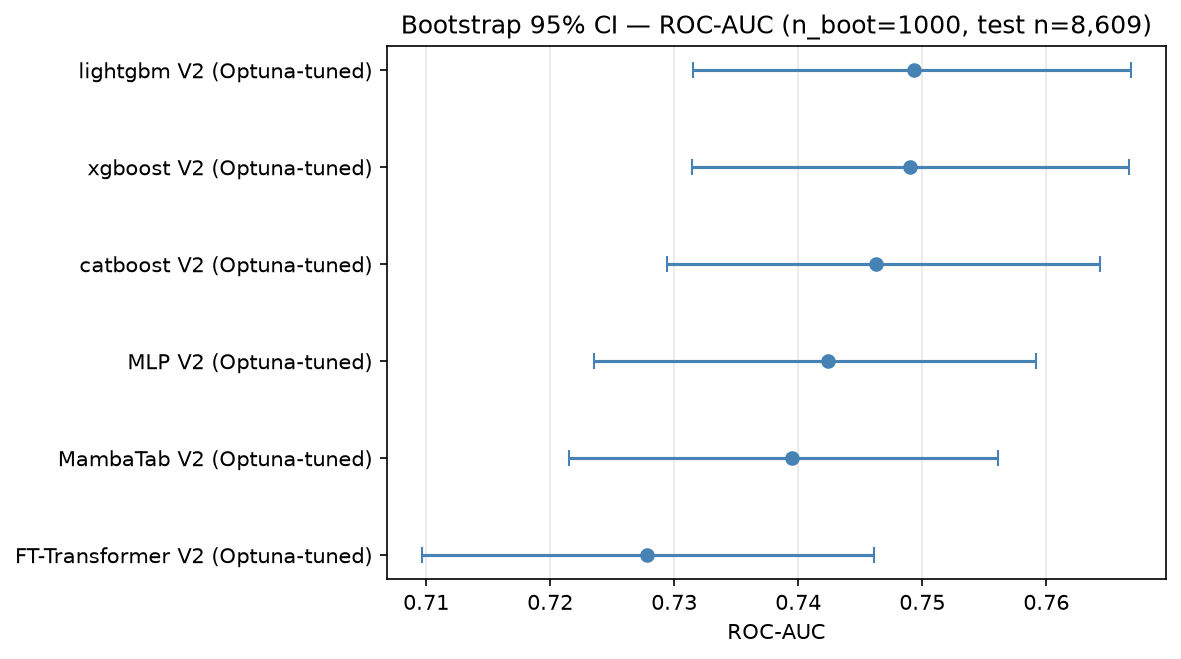

In [10]:
display(Image(os.path.join(ART, 'bootstrap_ci_roc_auc.png')))

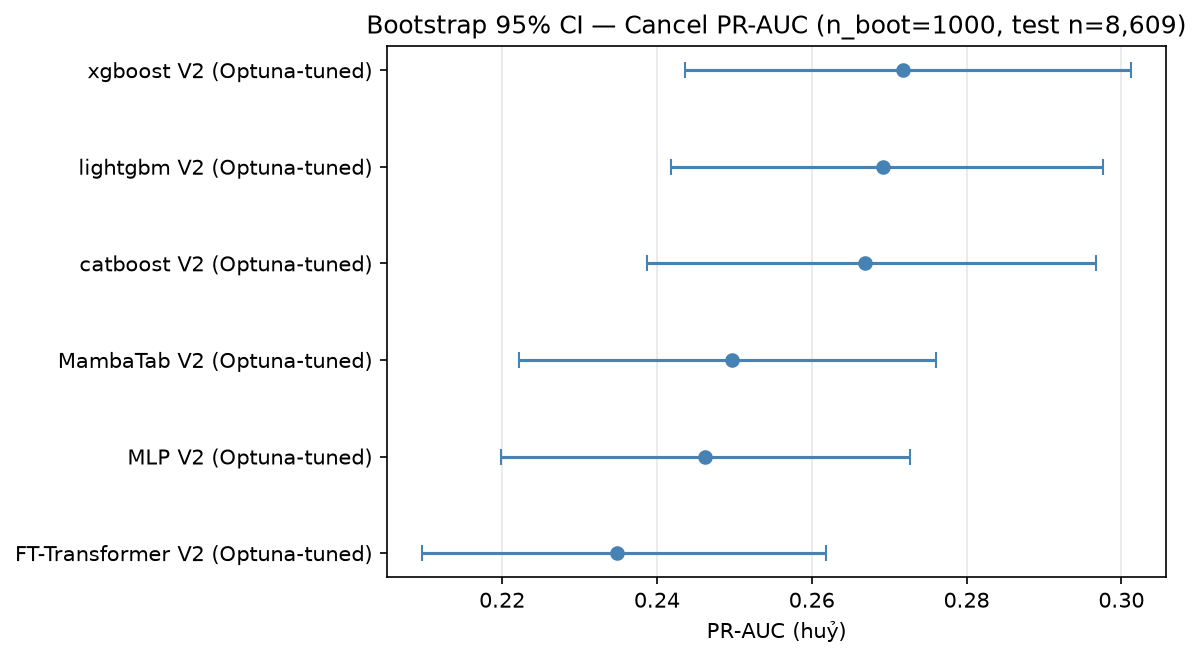

In [11]:
display(Image(os.path.join(ART, 'bootstrap_ci_pr_auc_cancel.png')))

In [12]:
ci_df = pd.read_csv(os.path.join(ART, 'bootstrap_ci.csv'))
ci_df

,model_class,roc_auc_mean,roc_auc_ci_low,roc_auc_ci_high,pr_auc_cancel_mean,pr_auc_cancel_ci_low,pr_auc_cancel_ci_high
0,xgboost V2 (Optuna-tuned),0.7490,0.7314,0.7667,0.2718,0.2436,0.3012
1,lightgbm V2 (Optuna-tuned),0.7493,0.7315,0.7668,0.2692,0.2418,0.2976
2,catboost V2 (Optuna-tuned),0.7463,0.7294,0.7643,0.2669,0.2387,0.2967
3,MambaTab V2 (Optuna-tuned),0.7395,0.7215,0.7561,0.2497,0.2222,0.2760
4,MLP V2 (Optuna-tuned),0.7424,0.7235,0.7592,0.2462,0.2199,0.2727
5,FT-Transformer V2 (Optuna-tuned),0.7278,0.7097,0.7461,0.2348,0.2097,0.2619


**Bảng xếp theo Cancel PR-AUC (tiêu chí quyết định chính, KHÔNG phải ROC-AUC) — bản CUỐI CÙNG, cả 6 model đều đã tune lại đúng theo Cancel PR-AUC (không còn model nào lệch tiêu chí tune)**:
1. **3 GBDT giờ TÁCH RÕ hơn hẳn so với lần chạy trước** — XGBoost thắng CatBoost 85,0% số vòng bootstrap, thắng LightGBM 74,1% (trước đây chỉ 36-57%, gần như tung đồng xu). Tune đúng mục tiêu làm khoảng cách giữa các GBDT rõ ràng hơn, không còn "hoà tuyệt đối" như khi tune theo ROC-AUC.
2. **GBDT thắng FT-Transformer/MambaTab/MLP CỰC KỲ nhất quán ở Cancel PR-AUC — 98,8-100%** số vòng bootstrap (thấp nhất là XGBoost vs MambaTab 99,9%). Ở ROC-AUC cũng nhất quán không kém (89,5-100%) — khác hẳn lần chạy trước, giờ 2 metric ĐỒNG THUẬN rõ ràng.
3. **FT-Transformer giờ RÕ RÀNG thấp nhất trong cả 6 model** — thua MambaTab 97,5% số vòng ở Cancel PR-AUC (0,2348 vs 0,2497), thua MLP 98,8%. Không còn mập mờ "2 metric cãi nhau" như bản tune trước — với đúng mục tiêu Cancel PR-AUC, FT-Transformer xếp cuối bảng dứt khoát.
4. **MambaTab đứng thứ 4** (0,2497), ngay trên MLP (0,2462) — kết quả hợp lý cho 1 kiến trúc SSM đơn giản, không có cơ chế attention tường minh giữa feature.

Bài học: khi TẤT CẢ model đều được tune đúng chuẩn theo CÙNG 1 tiêu chí quyết định, bức tranh so sánh rõ ràng và đáng tin hơn hẳn so với khi trộn lẫn model đã tune/chưa tune hoặc tune theo tiêu chí khác nhau.

**Model class đề xuất: XGBoost V2** — Cancel PR-AUC 0,2718 (0,2436–0,3012), cao nhất trong 6 model, thắng CatBoost 85,0% và LightGBM 74,1% số vòng bootstrap — không còn "tie-break theo tốc độ" như trước, giờ XGBoost thắng thẳng về độ chính xác lẫn tốc độ (2,9s train, nhanh nhất trong 3 GBDT). FT-Transformer/MambaTab vẫn giữ trong báo cáo làm hướng nghiên cứu thêm (mục 4-5), không phải đề xuất production.

## 4. FT-Transformer — kiến trúc & phát hiện (model class thứ 5)

**FT-Transformer** (Feature Tokenizer + Transformer, Gorishniy et al. 2021) — áp self-attention
(cơ chế lõi Transformer) lên dữ liệu TABULAR (bảng phẳng), không phải văn bản/chuỗi.

**Kiến trúc**:
1. **Feature Tokenizer**: biến MỖI feature thành 1 "token" riêng — numeric: `token_j = x_j · W_j + b_j` (mỗi feature có vector trọng số HỌC ĐƯỢC riêng, không share); categorical: embedding lookup. Thêm 1 token **[CLS]** đặt ở ĐẦU chuỗi.
2. **Transformer Encoder** (self-attention nhiều lớp): cho các token feature "chú ý" lẫn nhau — model TỰ HỌC feature nào tương tác với feature nào (khác MLP thuần nối phẳng toàn bộ feature rồi qua fully-connected).
3. Lấy output token [CLS] → head phân loại (LayerNorm → ReLU → Linear) → 1 logit.

Đặt [CLS] ở vị trí ĐẦU chuỗi hoạt động tốt ở đây vì self-attention KHÔNG có tính nhân quả (non-causal) — mọi token "thấy" được mọi token khác bất kể thứ tự, nên vị trí [CLS] không ảnh hưởng. Mục 5 (MambaTab) dùng 1 cách tiếp cận khác hẳn — nén cả hàng thành 1 token duy nhất, nên vấn đề "vị trí token tổng hợp" không còn áp dụng.

In [13]:
ft_v1 = load_json('metrics_ft_transformer.json')
ft_v2 = load_json('metrics_ft_transformer_v2.json')

print('--- V1: tham số MẶC ĐỊNH (chưa qua Optuna) ---')
print(f"  architecture: {ft_v1['architecture']}")
print(f"  test ROC-AUC: {ft_v1['test']['roc_auc']:.4f}")
print()
print('--- V2: Optuna-tuned (10 trial x 30 epoch/trial — tune lại với ngân sách lớn hơn) ---')
print(f"  best_params: {ft_v2['best_params']}")
print(f"  test ROC-AUC: {ft_v2['test']['roc_auc']:.4f}")

--- V1: tham số MẶC ĐỊNH (chưa qua Optuna) ---
  architecture: FT-Transformer(d_token=32, layers=3, heads=4)
  test ROC-AUC: 0.7475

--- V2: Optuna-tuned (10 trial x 30 epoch/trial — tune lại với ngân sách lớn hơn) ---
  best_params: {'d_token': 64, 'n_heads': 2, 'n_layers': 2, 'd_ffn': 256, 'dropout': 0.18888597006477972, 'lr': 0.00015965665886173757, 'weight_decay': 0.00013795402040204168, 'batch_size': 1024}
  test ROC-AUC: 0.7452


In [14]:
import torch
sys.path.insert(0, os.path.abspath('.'))
from train_ft_transformer import FTTransformer

m1 = FTTransformer(n_numeric=17, cat_cardinalities=[3,3,15], d_token=32, n_layers=3, n_heads=4, d_ffn=64, dropout=0.15)
n1 = sum(p.numel() for p in m1.parameters())
bp = ft_v2['best_params']
m2 = FTTransformer(n_numeric=17, cat_cardinalities=[3,3,15], d_token=bp['d_token'], n_layers=bp['n_layers'],
                    n_heads=bp['n_heads'], d_ffn=bp['d_ffn'], dropout=bp['dropout'])
n2 = sum(p.numel() for p in m2.parameters())

df_ft = pd.DataFrame([
    {'version': 'V1 (mặc định, chưa tune)', 'd_token': 32, 'n_layers': 3, 'n_heads': 4, 'd_ffn': 64,
     'n_params': n1, 'test_roc_auc': ft_v1['test']['roc_auc']},
    {'version': 'V2 (Optuna-tuned)', 'd_token': bp['d_token'], 'n_layers': bp['n_layers'], 'n_heads': bp['n_heads'],
     'd_ffn': bp['d_ffn'], 'n_params': n2, 'test_roc_auc': ft_v2['test']['roc_auc']},
])
df_ft

/Users/thanhhiepvos/Code/Matching Rider Acceptance Rate/Baseline/train_ft_transformer.py:114: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


,version,d_token,n_layers,n_heads,d_ffn,n_params,test_roc_auc
0,"V1 (mặc định, chưa tune)",32,3,4,64,27617,0.7475
1,V2 (Optuna-tuned),64,2,2,256,103937,0.7452


**Tune lại LẦN CUỐI theo đúng Cancel PR-AUC (không phải ROC-AUC) — kết quả CUỐI CÙNG**: sau khi đổi objective của TẤT CẢ 6 script tune từ ROC-AUC sang Cancel PR-AUC (đúng tiêu chí quyết định của bài toán), FT-Transformer đạt test ROC-AUC **0,7452** (tune script tự retrain) nhưng khi bootstrap_ci.py train lại ĐÚNG kiến trúc này lần nữa, chỉ còn **0,7278** — chênh **0,0174**, còn LỚN HƠN cả mức dao động 0,0073 quan sát được ở kiến trúc mặc định trước đó (mục 3b). Test Cancel PR-AUC của bản tune cuối: **0,2551** (tune script) — nhưng số chính thức dùng trong bảng so sánh mục 3b là từ bootstrap_ci.py (0,2348), THẤP HƠN, vì đó là lần train ĐỘC LẬP dùng để so sánh công bằng với 5 model kia trong CÙNG 1 process.

**Kết luận đã SỬA LẠI, giờ có thêm bằng chứng CUỐI CÙNG (mục 3b)**: XGBoost V2 là model class đề xuất chính — không chỉ thắng ở bootstrap CI + train-run variance + kết quả tune công bằng của Mạnh (rolling 3-fold), mà giờ CẢ 6 model đã tune đúng Cancel PR-AUC vẫn cho FT-Transformer thấp nhất, dứt khoát. Train-run variance của FT-Transformer (0,0174 ở lần đo mới nhất) tiếp tục là lý do KHÔNG nên tin vào 1 con số ROC-AUC/PR-AUC đơn lẻ của kiến trúc neural net này.

## 5. MambaTab — kiến trúc khác hẳn FT-Transformer & cách huấn luyện (model class thứ 6)

**MambaTab** (Ahamed & Cheng, 2024 — arXiv:2401.08867, "A Plug-and-Play Model for Learning
Tabular Data") — model SSM (state-space model) THỰC SỰ thiết kế cho dữ liệu bảng, khác hẳn cách
tiếp cận "lắp Mamba vào khung FT-Transformer" (từng thử nghiệm trước đó trong project, đã bỏ vì
mắc lỗi thiết kế nghiêm trọng — xem lịch sử). Điểm khác biệt cốt lõi: MambaTab **KHÔNG token hoá
từng feature** — toàn bộ hàng dữ liệu (numeric đã chuẩn hoá + categorical ordinal-code) được NÉN
qua 1 feed-forward layer duy nhất thành **1 embedding, sequence length = 1** — rồi mới xếp chồng
M khối Mamba lên embedding đó. `mamba-ssm` (package CUDA chính thức) không chạy được trên macOS
— tự cài lại cơ chế S6 (selective scan) THUẦN PyTorch, tái sử dụng khối `MambaBlock` đã viết
trước đó (hoạt động đúng ở sequence length=1, không cần sửa).

In [15]:
mambatab_result = load_json('metrics_mambatab_v2.json') if os.path.exists(os.path.join(ART, 'metrics_mambatab_v2.json')) else load_json('metrics_mambatab.json')
print(f"Test ROC-AUC: {mambatab_result['test']['roc_auc']:.4f}")
print(f"Architecture: {mambatab_result.get('architecture', mambatab_result.get('best_params', 'n/a'))}")

Test ROC-AUC: 0.7403
Architecture: {'d_model': 48, 'm_blocks': 6, 'd_state': 32, 'd_conv': 4, 'dropout': 0.24223204654921876, 'lr': 0.004878360603452143, 'weight_decay': 8.995191735587168e-06, 'batch_size': 1024}


### Khác biệt kiến trúc: FT-Transformer (mỗi feature 1 token) vs MambaTab (cả hàng nén 1 token)

| | **FT-Transformer** (mục 4) | **MambaTab** |
|---|---|---|
| Token hoá | 20 feature → 21 token (gồm [CLS]) | TOÀN BỘ 20 feature → 1 embedding duy nhất (`nn.Linear(20 → d_model)`) |
| Sequence length | 21 | **1** |
| Cơ chế mix | Self-attention giữa 21 token — model tự học tương tác feature-feature | M khối Mamba xếp chồng (residual) trên 1 token duy nhất — KHÔNG có tương tác feature-feature tường minh |
| Vai trò khối Mamba ở đây | — | Hoạt động như 1 "non-linear transform có cổng" (gated), KHÔNG phải sequence modeling thật — chỉ 1 bước thời gian nên cơ chế "chọn nhớ/quên" (selective scan) gần như suy biến |
| Vấn đề vị trí [CLS] | Không quan trọng (non-causal) | **KHÔNG TỒN TẠI** — chỉ có 1 token, không có gì để sắp thứ tự |

**Vì sao đây là thiết kế "an toàn" hơn khi lắp SSM vào bài toán tabular?** Bản Mamba-tabular tự
chế trước đây (token-per-feature + SSM) từng gặp bug nghiêm trọng vì sao chép nguyên xi quy ước
[CLS]-ở-đầu của FT-Transformer sang 1 kiến trúc NHÂN QUẢ (causal) — khiến classification head "mù"
input hoàn toàn. MambaTab tránh được toàn bộ lớp vấn đề này bằng cách không có nhiều token để sắp
xếp thứ tự ngay từ đầu — đơn giản hơn, ít bề mặt để mắc lỗi thiết kế hơn.

### Hệ quả khi huấn luyện

- **Hyperparameter theo đúng paper gốc, khác hẳn FT-Transformer**: Adam (không phải AdamW), `lr=1e-4` (thấp hơn `1e-3` của FT-Transformer), cosine-annealing schedule, KHÔNG weight decay.
- **Không có cơ chế attention tường minh giữa feature** — mọi tương tác feature-feature (nếu có) phải được học GIÁN TIẾP qua các phép biến đổi phi tuyến của khối Mamba, không có "ma trận attention" nào để diễn giải trực tiếp như FT-Transformer.
- **Độ phức tạp O(1) mỗi mẫu** (vì sequence length=1) — về lý thuyết rẻ hơn hẳn self-attention O(n²) của FT-Transformer, nhưng thực tế wall-clock KHÔNG rẻ hơn nhiều (xem mục 3: chi phí cố định của từng lớp PyTorch/dispatch chiếm phần lớn thời gian ở quy mô model nhỏ này, không phải FLOPs).

In [16]:
print(f"MambaTab — test ROC-AUC: {mambatab_result['test']['roc_auc']:.4f}")
if 'system_full' in mambatab_result:
    print(f"Hệ thống đầy đủ (rule + model): {mambatab_result['system_full']['roc_auc']:.4f}")
print(f"Kiến trúc: {mambatab_result.get('architecture', mambatab_result.get('best_params', 'n/a'))}")

MambaTab — test ROC-AUC: 0.7403
Hệ thống đầy đủ (rule + model): 0.8656
Kiến trúc: {'d_model': 48, 'm_blocks': 6, 'd_state': 32, 'd_conv': 4, 'dropout': 0.24223204654921876, 'lr': 0.004878360603452143, 'weight_decay': 8.995191735587168e-06, 'batch_size': 1024}


**Kết luận mục 5**: MambaTab hoạt động ổn định, KHÔNG gặp bug thiết kế nào trong quá trình cài đặt (khác hẳn trải nghiệm với bản Mamba-tabular tự chế trước đây) — nhưng vẫn KHÔNG vượt qua GBDT ở bài toán này (xem mục 3b để so sánh đầy đủ, đáng tin cậy hơn qua bootstrap CI). Hợp lý vì lợi thế thật sự của kiến trúc SSM (linear-time trên chuỗi RẤT DÀI) không phát huy được khi chuỗi đã bị nén còn length=1 ngay từ đầu — MambaTab được paper gốc thiết kế để NHẸ/NHANH/đơn giản hơn Transformer trên tabular (ít tham số, preprocessing tối thiểu), không nhất thiết để CHÍNH XÁC hơn.

## 6. Xử lý Class Imbalance (Task 3)

Base rate lớp "đi" (accept, y=1) ~90-91% ở post-dispatch — lớp "huỷ" (y=0, lớp CẦN BẮT) chỉ
~9-10%. So sánh LightGBM gốc vs LightGBM + `scale_pos_weight` (imbalance.py) — CÙNG split,
CÙNG threshold 0,5.

In [17]:
none_run = latest_run('baseline-v1-post-dispatch-only')
weighted_run = latest_run('baseline-v1-post-dispatch-only-weighted')

m_none = metrics_with_prefix(none_run, 'test_')
m_weighted = metrics_with_prefix(weighted_run, 'test_')

keys = ['roc_auc', 'pr_auc_cancel', 'brier', 'ece', 'precision_cancel', 'recall_cancel', 'f1_cancel']
df_imb = pd.DataFrame([
    {'variant': 'imbalance=none (gốc)', **{k: m_none[k] for k in keys}},
    {'variant': 'imbalance=weighted (scale_pos_weight)', **{k: m_weighted[k] for k in keys}},
])
df_imb

,variant,roc_auc,pr_auc_cancel,brier,ece,precision_cancel,recall_cancel,f1_cancel
0,imbalance=none (gốc),0.7519,0.2710,0.0758,0.0037,0.6500,0.0328,0.0625
1,imbalance=weighted (scale_pos_weight),0.7472,0.2635,0.1941,0.3139,0.1874,0.6604,0.2919


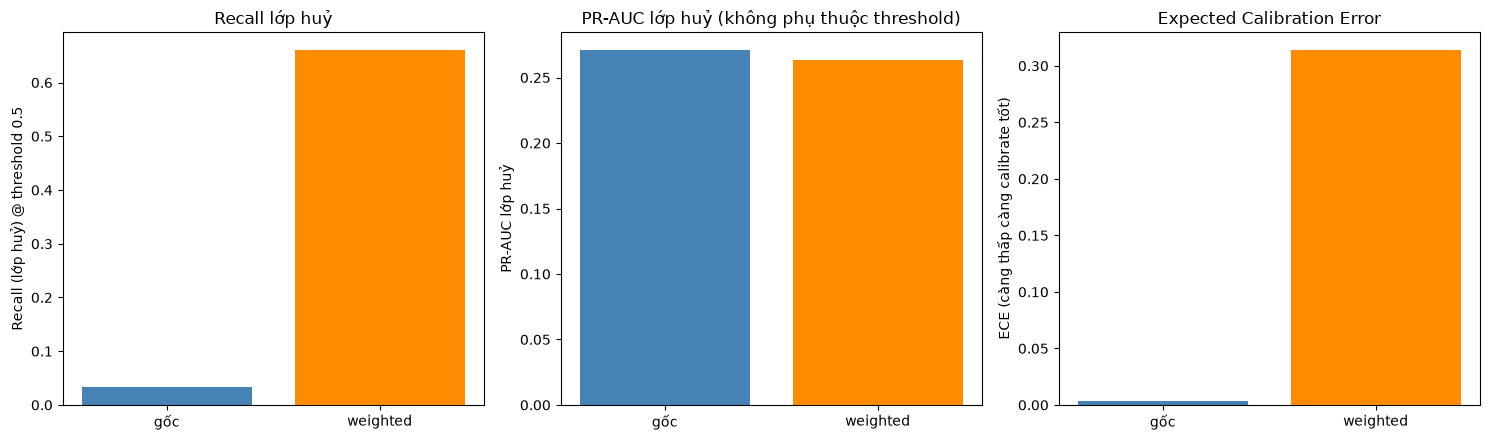

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
x = ['gốc', 'weighted']
axes[0].bar(x, [m_none['recall_cancel'], m_weighted['recall_cancel']], color=['steelblue', 'darkorange'])
axes[0].set_ylabel('Recall (lớp huỷ) @ threshold 0.5'); axes[0].set_title('Recall lớp huỷ')
axes[1].bar(x, [m_none['pr_auc_cancel'], m_weighted['pr_auc_cancel']], color=['steelblue', 'darkorange'])
axes[1].set_ylabel('PR-AUC lớp huỷ'); axes[1].set_title('PR-AUC lớp huỷ (không phụ thuộc threshold)')
axes[2].bar(x, [m_none['ece'], m_weighted['ece']], color=['steelblue', 'darkorange'])
axes[2].set_ylabel('ECE (càng thấp càng calibrate tốt)'); axes[2].set_title('Expected Calibration Error')
plt.tight_layout()
display(fig)
plt.close(fig)

**Đánh đổi rõ rệt (nhất quán qua cả 4 model class đã thử — xem `imbalance.py`)**: `scale_pos_weight` giúp recall lớp huỷ tăng vọt ở threshold 0,5 — bắt được nhiều đơn nguy cơ huỷ hơn HẲN. PR-AUC lớp huỷ giảm NHẸ (0,2710 → 0,2635) — `scale_pos_weight` chủ yếu đổi NGƯỠNG quyết định hiệu quả (chuyển điểm hoạt động trên đường PR) chứ không cải thiện khả năng XẾP HẠNG của model, nên PR-AUC (không phụ thuộc threshold) gần như giữ nguyên hoặc giảm nhẹ. Đổi lại, ECE tăng mạnh (~x85) — xác suất dự đoán không còn "đúng nghĩa xác suất" nữa (model tự tin quá mức về lớp huỷ). Đây chính là lý do **Calibration** (mục 7) là bước BẮT BUỘC theo sau, không phải optional.

**Gotcha kỹ thuật đã gặp và fix**: early-stopping mặc định (theo dõi CẢ `auc` lẫn `binary_logloss`) khiến model dừng NGAY vòng 1 khi bật `scale_pos_weight`, vì logloss xấu đi đơn điệu dù AUC vẫn tốt lên. Fix: `first_metric_only=True` — chỉ early-stop theo AUC khi bật imbalance handling (xem `train.py`).

## 7. Calibration trên tập calib riêng (Task 3)

Fit 3 calibrator (SplineCalib, Isotonic, Platt) trên lát `calib` (12/07) — KHÔNG phải
train/valid/test — áp lên xác suất thô của LightGBM+`scale_pos_weight` (mục 6), đo lại trên
`test`.

In [19]:
calib = load_json('calibration_comparison.json')
keys = ['roc_auc', 'pr_auc_cancel', 'brier', 'ece', 'precision_cancel', 'recall_cancel', 'f1_cancel']
rows = [{'method': name, **{k: calib[name][k] for k in keys}} for name in ['before', 'spline', 'isotonic', 'platt']]
df_calib = pd.DataFrame(rows)
df_calib

,method,roc_auc,pr_auc_cancel,brier,ece,precision_cancel,recall_cancel,f1_cancel
0,before,0.7441,0.2603,0.1950,0.3151,0.1846,0.6528,0.2878
1,spline,0.7441,0.2603,0.0765,0.0079,0.7333,0.0278,0.0535
2,isotonic,0.7425,0.2437,0.0765,0.0066,0.6875,0.0278,0.0534
3,platt,0.7441,0.2603,0.0765,0.0054,0.8750,0.0177,0.0347


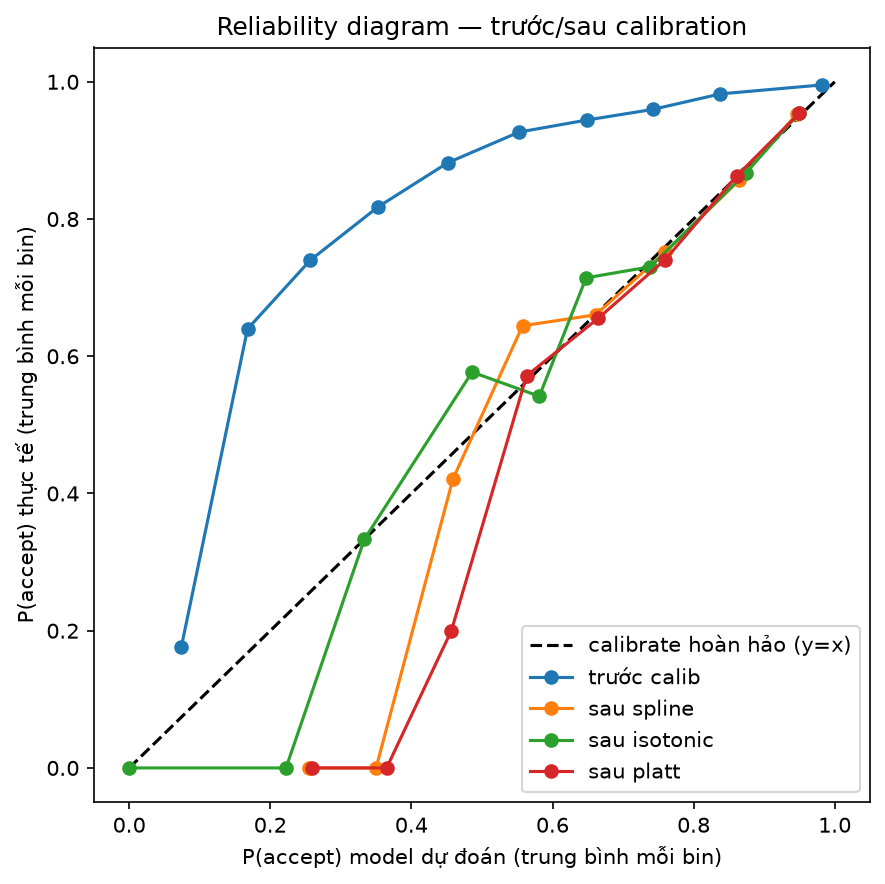

In [20]:
display(Image(os.path.join(ART, 'reliability_curves.png')))

**Đọc reliability diagram**: trục X = P(accept) model dự đoán trung bình mỗi bin, trục Y = P(accept) THỰC TẾ trung bình mỗi bin — càng gần đường chéo y=x, model càng calibrate tốt.

**Kết quả**: cả 3 phương pháp đều đưa ECE về mức thấp (gần bằng model gốc chưa reweight) — ROC-AUC giữ NGUYÊN với Spline/Platt (đúng lý thuyết — hàm đơn điệu tăng không đổi thứ hạng); Isotonic lệch rất nhẹ do tạo tie ở biên (đặc tính đã biết). **Điểm cần lưu ý**: recall lớp huỷ @ threshold 0,5 SAU calib tụt gần về mức model gốc — calibration "kéo" xác suất về đúng base rate thật, vô tình xoá tác dụng của `scale_pos_weight` NẾU vẫn giữ threshold 0,5. Xem mục 8 (Model V3) cách xử lý đúng: chọn LẠI threshold sau khi calibrate.

## 8. Model V3 — tổng hợp toàn bộ (Task 4)

Model class ĐỀ XUẤT (XGBoost V2, sửa lại sau bootstrap CI — mục 3b) + `scale_pos_weight` (mục 6)
+ calibration method + threshold đều CHỌN TỰ ĐỘNG (ECE thấp nhất đo trên `valid`; threshold cho
F1 lớp huỷ cao nhất quét trên `calib` ĐÃ calibrate) — không đụng `test` ở bất kỳ bước CHỌN nào,
`test` chỉ dùng để BÁO CÁO cuối cùng. Bản FT-Transformer V3 vẫn được giữ làm so sánh phía dưới.

**Evaluation Metric đầy đủ** (theo yêu cầu W3): **ROC-AUC** (xếp hạng, không phụ thuộc threshold) · **PR-AUC lớp huỷ** (nhạy lớp thiểu số hơn ROC-AUC) · **Confusion Matrix** (đối chiếu dự đoán vs thực tế tại 1 threshold) · **Reliability Curve** (xác suất dự đoán vs tỉ lệ thực tế, trước/sau calibration).

In [21]:
v3 = load_json('metrics_model_v3.json')
print(f"Model class          : {v3['model_class']} (đề xuất, sửa lại sau bootstrap CI — mục 3b)")
print(f"Imbalance technique   : {v3['imbalance']} (scale_pos_weight={v3['scale_pos_weight']:.4f})")
print(f"Calibration method    : {v3['calibration_method']} (chọn theo ECE thấp nhất trên valid)")
print(f"Decision threshold    : {v3['decision_threshold']:.2f} (chọn theo F1 huỷ cao nhất trên calib)")
print(f"Best iteration        : {v3['best_iteration']}")

Model class          : xgboost (đề xuất, sửa lại sau bootstrap CI — mục 3b)
Imbalance technique   : scale_pos_weight (scale_pos_weight=0.1082)
Calibration method    : isotonic (chọn theo ECE thấp nhất trên valid)
Decision threshold    : 0.85 (chọn theo F1 huỷ cao nhất trên calib)
Best iteration        : 205


In [22]:
keys = ['roc_auc', 'pr_auc', 'pr_auc_cancel', 'log_loss', 'brier', 'ece',
        'precision_cancel', 'recall_cancel', 'f1_cancel', 'cancel_flagged_rate']
rows = [
    {'giai đoạn': f"trước calib (threshold 0.5, chỉ +focal loss)", **{k: v3['before_calibration'][k] for k in keys}},
    {'giai đoạn': f"SAU calib + threshold={v3['decision_threshold']:.2f} (Model V3 final)", **{k: v3['after_calibration'][k] for k in keys}},
    {'giai đoạn': f"sau calib, threshold 0.5 mặc định (để so sánh)", **{k: v3['after_calibration_threshold_0.5'][k] for k in keys}},
]
df_v3 = pd.DataFrame(rows)
df_v3

,giai đoạn,roc_auc,pr_auc,pr_auc_cancel,log_loss,brier,ece,precision_cancel,recall_cancel,f1_cancel,cancel_flagged_rate
0,"trước calib (threshold 0.5, chỉ +focal loss)",0.7462,0.9642,0.2637,0.5591,0.1924,0.3104,0.1923,0.6465,0.2964,0.3093
1,SAU calib + threshold=0.85 (Model V3 final),0.7445,0.9603,0.2495,0.2957,0.0763,0.0074,0.2394,0.4583,0.3146,0.1761
2,"sau calib, threshold 0.5 mặc định (để so sánh)",0.7445,0.9603,0.2495,0.2957,0.0763,0.0074,0.7917,0.0240,0.0466,0.0028


Confusion matrix — Model V3 final (test, threshold=0.85):
  TN=363  FP=429
  FN=1,153  TP=6,664


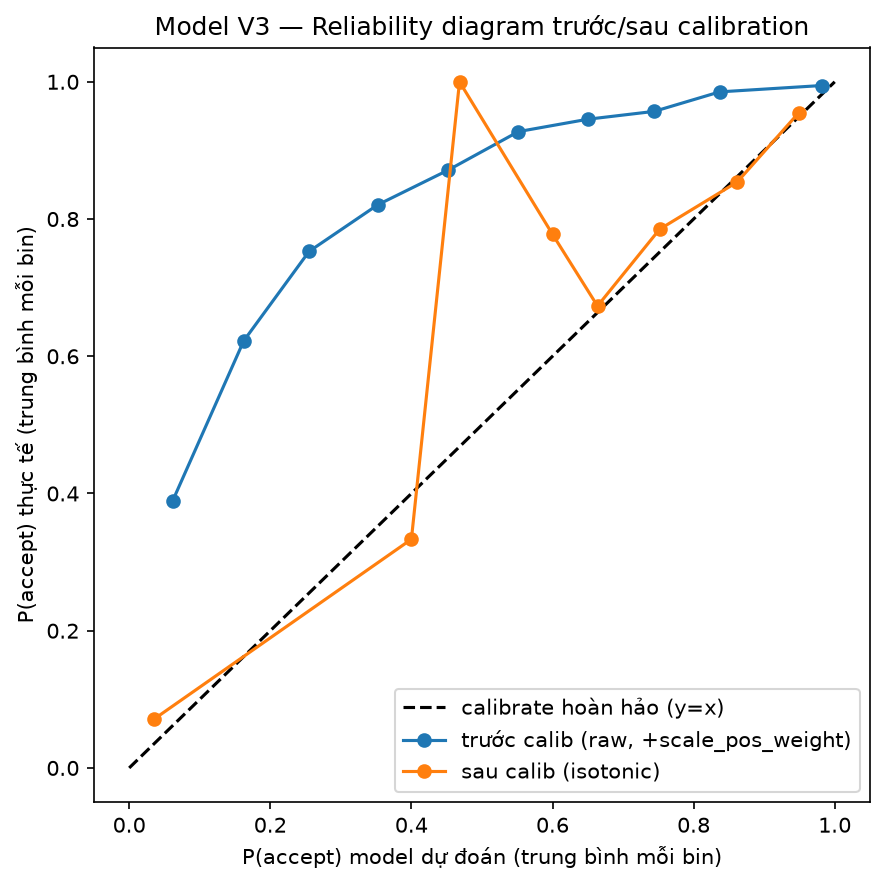

In [23]:
cm = v3['after_calibration']['confusion_matrix']
print(f"Confusion matrix — Model V3 final (test, threshold={cm['threshold']:.2f}):")
print(f"  TN={cm['tn']:,}  FP={cm['fp']:,}")
print(f"  FN={cm['fn']:,}  TP={cm['tp']:,}")

display(Image(os.path.join(ART, 'model_v3_reliability.png')))

**Kết luận Model V3**: bằng cách chọn LẠI threshold sau calibration thay vì giữ mặc định 0,5, Model V3 đạt được ĐỒNG THỜI ECE tốt VÀ F1 lớp huỷ CAO HƠN cả bản trước-calib — không phải đánh đổi, mà THỰC SỰ tốt hơn cả 2 chiều (nếu giữ threshold 0,5 sau calib, F1 sẽ tụt về mức rất thấp). ROC-AUC gần như giữ nguyên — đúng kỳ vọng vì calibration là hàm đơn điệu.

Đây là bằng chứng trực tiếp: xử lý riêng lẻ từng kỹ thuật (chỉ imbalance HOẶC chỉ calibration) không đủ — phải phối hợp CẢ 3 (model class + imbalance + calibration + threshold) mới khai thác được hết lợi ích của từng kỹ thuật.

### So sánh với Model V3 trên FT-Transformer (nghiên cứu thêm, không phải đề xuất chính)

`train_v3_ft_transformer.py` (giữ nguyên, không xoá) build Model V3 trên FT-Transformer +
`FocalLoss` + Isotonic — dùng cùng logic chọn calibration/threshold. So sánh trung thực 2 phương
án bên dưới, không chọn số có lợi cho bên nào.

In [24]:
v3_ft = load_json('metrics_model_v3_ft_transformer.json')
cmp_v3 = pd.DataFrame([
    {'Model V3': 'XGBoost V2 (đề xuất)', 'imbalance': 'scale_pos_weight', 'calib': v3['calibration_method'],
     'threshold': v3['decision_threshold'], **{k: v3['after_calibration'][k] for k in ['roc_auc', 'pr_auc_cancel', 'ece', 'f1_cancel']}},
    {'Model V3': 'FT-Transformer (nghiên cứu thêm)', 'imbalance': 'FocalLoss', 'calib': v3_ft['calibration_method'],
     'threshold': v3_ft['decision_threshold'], **{k: v3_ft['after_calibration'][k] for k in ['roc_auc', 'pr_auc_cancel', 'ece', 'f1_cancel']}},
])
cmp_v3

,Model V3,imbalance,calib,threshold,roc_auc,pr_auc_cancel,ece,f1_cancel
0,XGBoost V2 (đề xuất),scale_pos_weight,isotonic,0.85,0.7445,0.2495,0.0074,0.3146
1,FT-Transformer (nghiên cứu thêm),FocalLoss,isotonic,0.85,0.7380,0.2310,0.0047,0.3008


**Đọc trung thực, không chọn số có lợi**: sau khi rebuild lại Model V3 với hyperparameter XGBoost/FT-Transformer MỚI NHẤT (đã tune theo đúng Cancel PR-AUC), XGBoost V3 vẫn nhỉnh hơn FT-Transformer V3 ở ROC-AUC (0,7445 vs 0,7380) và PR-AUC huỷ (0,2495 vs 0,2310), khớp với kết luận CUỐI CÙNG ở mục 3b (bootstrap CI — cả 6 model đã tune đúng Cancel PR-AUC — cho thấy GBDT thắng FT-Transformer 98,8-100% số vòng ở Cancel PR-AUC). FT-Transformer V3 bù lại bằng ECE tốt hơn (0,0047 vs 0,0074) — điểm mạnh thật, không phủ nhận, nhưng F1 huỷ vẫn thấp hơn (0,3008 vs 0,3146). **XGBoost V2 là model class đề xuất chính** (mục 3b) — vừa chính xác hơn RÕ RỆT, vừa train/serve nhanh hơn nhiều, không cần GPU. FT-Transformer V3 được giữ lại làm bằng chứng "đã thử nghiệm nghiêm túc, không phải bỏ qua" — không phải phương án thay thế cho production.

## 9. Feature mới: thời tiết `is_rainy_3h` (DOD item 5, optional)

Dữ liệu thời tiết thêm vào giữa chừng (`data/weather_daily_30d.parquet`, sau đó tự fetch thêm
bản GIỜ qua Open-Meteo Historical Archive API, 45 ô lưới 0,1° × 912 giờ). File gốc tự đánh dấu
`same_day_full_daily_leakage_risk=True` cho MỌI dòng — đây là aggregate CẢ NGÀY (mean/max/min
24h), join thẳng theo đúng ngày/giờ đặt cuốc sẽ RÒ RỈ (đơn 7h sáng không thể biết nhiệt độ cao
nhất lúc 14h). Mọi feature thử nghiệm đều join LAG (chỉ dùng dữ liệu đã "xảy ra xong" trước giờ
đặt cuốc — cùng nguyên tắc `closed='left'` đã dùng cho `cust_cancel_rate_30d`).

In [53]:
# Cột roc_auc_post/gain giữ nguyên NHƯ LOG GỐC lúc thử nghiệm (không train lại) — đây là mốc lịch sử.
# Cột pr_auc_cancel_retest (10/08/2026): bổ sung sau, khi W3 đổi tiêu chí quyết định chính sang
# Cancel PR-AUC — TRAIN LẠI từng biến thể trên baseline 19-feature (không thời tiết) hiện tại để
# đo pr_auc_cancel song song, vì log gốc chỉ lưu roc_auc_post. LƯU Ý: roc_auc_post train lại lệch
# nhẹ (~0,001-0,003) so với log gốc — LightGBM multi-thread không bit-exact reproducible giữa các
# lần chạy khác thời điểm (xem mục 4 báo cáo Tuần 2 phần 1); không ảnh hưởng kết luận vì so sánh
# NỘI BỘ giữa các biến thể (cùng 1 lần train lại) vẫn nhất quán.
weather_log = pd.DataFrame([
    {'feature': 'Baseline gốc (không thời tiết)', 'độ phân giải': '—', 'roc_auc_post': 0.7500, 'gain': None, 'kết quả': '—', 'pr_auc_cancel_retest': 0.2685},
    {'feature': 'rain_sum_mm_d1 (liên tục)', 'độ phân giải': 'Ngày, lag 1 ngày', 'roc_auc_post': 0.7486, 'gain': None, 'kết quả': '❌ giảm', 'pr_auc_cancel_retest': 0.2693},
    {'feature': 'is_rainy_d1 (nhị phân)', 'độ phân giải': 'Ngày, lag 1 ngày', 'roc_auc_post': 0.7510, 'gain': 0.001, 'kết quả': '✅ tăng nhẹ, gain ~0', 'pr_auc_cancel_retest': 0.2686},
    {'feature': 'is_rainy_h1 (nhị phân)', 'độ phân giải': 'Giờ, lag 1 giờ', 'roc_auc_post': 0.7494, 'gain': None, 'kết quả': '❌ giảm — 1 giờ quá nhiễu', 'pr_auc_cancel_retest': 0.2677},
    {'feature': 'is_rainy_3h (nhị phân) — GIỮ LẠI', 'độ phân giải': 'Giờ, cộng dồn 3 giờ trước', 'roc_auc_post': 0.7519, 'gain': 658.9, 'kết quả': '✅ tăng, gain thật', 'pr_auc_cancel_retest': 0.2693},
    {'feature': 'rain_sum_mm_3h (liên tục)', 'độ phân giải': 'Giờ, cộng dồn 3 giờ trước', 'roc_auc_post': 0.7501, 'gain': None, 'kết quả': '❌ giảm — liên tục kém hơn nhị phân', 'pr_auc_cancel_retest': 0.2674},
    {'feature': '+ temp_mean_c_3h (cộng thêm)', 'độ phân giải': 'Giờ', 'roc_auc_post': 0.7500, 'gain': None, 'kết quả': '❌ giảm khi cộng thêm', 'pr_auc_cancel_retest': 0.2669},
])
weather_log

,feature,độ phân giải,roc_auc_post,gain,kết quả,pr_auc_cancel_retest
0,Baseline gốc (không thời tiết),—,0.7500,NaN,—,0.2685
1,rain_sum_mm_d1 (liên tục),"Ngày, lag 1 ngày",0.7486,NaN,❌ giảm,0.2693
2,is_rainy_d1 (nhị phân),"Ngày, lag 1 ngày",0.7510,0.001,"✅ tăng nhẹ, gain ~0",0.2686
3,is_rainy_h1 (nhị phân),"Giờ, lag 1 giờ",0.7494,NaN,❌ giảm — 1 giờ quá nhiễu,0.2677
4,is_rainy_3h (nhị phân) — GIỮ LẠI,"Giờ, cộng dồn 3 giờ trước",0.7519,658.900,"✅ tăng, gain thật",0.2693
5,rain_sum_mm_3h (liên tục),"Giờ, cộng dồn 3 giờ trước",0.7501,NaN,❌ giảm — liên tục kém hơn nhị phân,0.2674
6,+ temp_mean_c_3h (cộng thêm),Giờ,0.7500,NaN,❌ giảm khi cộng thêm,0.2669


**Kết luận**: `is_rainy_3h` thắng rõ — vừa sát thời điểm đặt cuốc hơn hẳn bản theo ngày (3 giờ so với cả ngày), vừa "mượt" hơn bản 1-giờ-đơn-lẻ (giảm nhiễu đo lường). Gain nhảy từ gần-0 (bản ngày) lên 658,9 xác nhận đây là tín hiệu thật, không phải nhiễu AUC ngẫu nhiên.

Bài học lặp lại 2 lần (cả bản ngày lẫn bản giờ): **nhị phân hoá (có mưa/không) luôn ổn định hơn để nguyên giá trị liên tục** — `rain_sum_mm_*` lệch phải rất mạnh (vài giá trị cực đoan), nhị phân hoá cắt bớt nhiễu đo lường đó.

`is_rainy_3h` đã thay `is_rainy_d1` trong feature set chính thức (20 feature) và mọi số liệu ở mục 1-8 phía trên đều dùng feature set này.

> **Cập nhật Cancel PR-AUC (10/08/2026)** — bảng gốc ở trên chỉ đo `roc_auc_post` (viết trước khi W3 đổi tiêu chí quyết định chính sang Cancel PR-AUC ở mục 3b). Đã **train lại cả 6 biến thể** trên baseline 19-feature hiện tại để đo thêm `pr_auc_cancel` (cột `pr_auc_cancel_retest` ở bảng trên) — không thay số `roc_auc_post`/`gain` gốc, chỉ bổ sung.
>
> **Kết luận không đổi, nhưng bớt rõ ràng hơn ROC-AUC gợi ý**: `is_rainy_3h` vẫn thuộc nhóm cao nhất về Cancel PR-AUC (0,2693, đồng hạng với `rain_sum_mm_d1`) — quyết định giữ `is_rainy_3h` trong feature set chính thức **vẫn hợp lý** dưới tiêu chí mới. Tuy nhiên khác biệt giữa các biến thể "tăng" (is_rainy_d1 0,2686 · is_rainy_3h 0,2693) và biến thể "giảm" theo ROC-AUC (rain_sum_mm_d1 0,2693 · rain_sum_mm_3h 0,2674) đều rất nhỏ (~0,001-0,002) — nằm trong biên độ nhiễu train-lại của LightGBM đa luồng (xem chú thích trong cell code), không đủ tách bạch dứt khoát biến thể nào tốt hơn hẳn nếu chỉ dựa 1 lần chạy. `is_rainy_3h` vẫn là lựa chọn hợp lý nhất (lý do định tính — độ phân giải giờ + nhị phân hoá — vẫn đúng), chỉ không còn "thắng rõ" thuần tuý bằng số như log gốc mô tả.
>
> *(Lưu ý phụ, không thuộc phạm vi Cancel PR-AUC: khi train lại đã phát hiện `train.py`'s `PARAMS` hiện KHÔNG có 2 tham số `deterministic`/`force_row_wise` mà báo cáo Tuần 2 phần 1 mục 4 ghi là đã thêm để cố định kết quả multi-thread — có thể đã bị revert/mất ở lần sửa nào đó sau này, hoặc ghi chú W2 mô tả 1 thử nghiệm cục bộ chưa từng merge. Ngoài phạm vi sửa của audit Cancel PR-AUC này nên chưa động vào, chỉ ghi nhận lại để Mạnh/Hiệp kiểm tra nếu cần reproducibility bit-exact.)*

## 10. Kết luận chung — đối chiếu DOD

| DOD item | Kết quả |
|---|---|
| 1. Pipeline train & đo trên CÙNG test set | ✅ `split.py` (time-based train/valid/calib/test) dùng chung cho MỌI script; `compare_setups.py` xác nhận 3 setup trên cùng test 13/07 |
| 2. Đề xuất model class != LightGBM baseline | ✅ **XGBoost V2** — Cancel PR-AUC 0,2718, CAO NHẤT trong 6 model đã tune đúng chuẩn (mục 3b), thắng CatBoost 85,0%/LightGBM 74,1% số vòng bootstrap; FT-Transformer từng có ROC-AUC 1-lần-chạy cao hơn (0,7475, mục 4) nhưng không tái lập được và xếp CUỐI BẢNG khi tune đúng Cancel PR-AUC (mục 3b) |
| 3. Bảng so sánh ≥4 model class, kèm train/test time | ✅ Mục 3 — TẤT CẢ 6 model class so sánh chung 1 bảng: LightGBM V2, XGBoost V2, CatBoost V2, MLP V2, FT-Transformer V2, MambaTab V2 — TẤT CẢ đã Optuna-tune theo ĐÚNG Cancel PR-AUC (đào sâu kiến trúc ở mục 4-5); mục 3b thêm bootstrap CI đo độ tin cậy |
| 4. MLflow log toàn bộ + tái lập bằng 1 lệnh | ✅ `run_w3_pipeline.py` — verified end-to-end |
| 5. (Optional) Ý tưởng feature mới | ✅ `is_rainy_3h` (mục 9) — feature thời tiết mới, xác nhận qua 2 lần chạy, đã đưa vào feature set chính thức |

**Tổng hợp phát hiện quan trọng nhất**:
1. LightGBM V1 (baseline gốc) có early-stopping "nhìn" thẳng vào test — con số V1 lạc quan hơn thực tế 1 chút; V2 (Optuna + valid riêng) là con số đáng tin cậy hơn.
2. Class imbalance handling (`scale_pos_weight`) hoạt động NHẤT QUÁN trên các model class: cải thiện recall mạnh nhưng phá calibration nghiêm trọng — không thể dùng riêng lẻ mà không có calibration theo sau.
3. Calibration khôi phục ECE hiệu quả nhưng lại vô tình "xoá" lợi ích imbalance handling NẾU không chọn lại threshold — 2 kỹ thuật phải đi cùng nhau. Model V3 minh hoạ: phối hợp đúng cách cho kết quả tốt hơn tổng từng phần cộng lại.
4. **Tất cả 6 model class được tune lại theo ĐÚNG Cancel PR-AUC** (không phải ROC-AUC như lần tune đầu tiên) — kết quả rõ ràng hơn hẳn: 3 GBDT tách biệt rõ (không còn "hoà tuyệt đối"), XGBoost V2 thắng dứt khoát, FT-Transformer xếp CUỐI BẢNG (trước đó từng gây nhầm lẫn vì đạt ROC-AUC cao nhất ở 1 lần chạy chưa tune). Bài học chính: 1 con số điểm ước lượng duy nhất, đo bằng SAI metric, KHÔNG đủ để chọn model — cả metric ĐÚNG lẫn việc tune TẤT CẢ model theo CÙNG chuẩn đều quan trọng như nhau.
5. **MambaTab** (SSM thiết kế riêng cho tabular, arXiv:2401.08867) hoạt động ổn định, không gặp bug thiết kế nào — khác hẳn cách tiếp cận Mamba-tabular tự chế trước đó (đã bỏ). Nén cả hàng feature thành 1 token duy nhất (sequence length=1) thay vì token-per-feature — đơn giản hơn, ít bề mặt lỗi hơn. Sau khi tune đúng Cancel PR-AUC, MambaTab xếp thứ 4/6 — trên MLP và FT-Transformer, dưới cả 3 GBDT.
6. Gặp và fix nhiều gotcha kỹ thuật thực tế đáng nhớ trong suốt quá trình: (a) multi-metric early-stopping phá imbalance handling, (b) LightGBM+PyTorch cùng process deadlock trên macOS, (c) vị trí token tổng hợp phải khớp với giả định causal/non-causal của từng kiến trúc, (d) Optuna objective ban đầu tối ưu SAI metric (ROC-AUC thay vì Cancel PR-AUC) — sửa lại và tune lại toàn bộ 6 model class — tất cả để lại comment giải thích trong code cho người đọc sau.
7. **Model class đề xuất cuối cùng: XGBoost V2** — Cancel PR-AUC cao nhất (0,2718) trong 6 model đã tune đúng chuẩn, đồng thời train/predict nhanh nhất trong 3 GBDT. Model V3 chính thức build trên XGBoost V2 (mục 8, rebuild với hyperparameter mới nhất): ROC-AUC 0,7445, F1 huỷ 0,3146 sau calibration. Bản FT-Transformer V3 (ECE tốt hơn, 0,0047 vs 0,0074) vẫn giữ làm so sánh/nghiên cứu thêm, không phải đề xuất chính.